# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# read in data as dataframe
df = pd.read_csv('foods_health_scores_allergens.csv')
df

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,Crème fraîche gastronomique,Président,"en:dairies, en:fermented-foods, en:fermented-m...","_Crème_ (origine France), _ferments lactiques_",D,3.0,A,en:milk,291.0,30.0,...,2.3,0.070000,0.028000,False,True,False,False,False,False,Branded/Packaged
4993,Noix de cajou grillées sans sel,Maître Prunille,"en:plant-based-foods-and-beverages, en:plant-b...",Noix de cajou,B,1.0,E,en:nuts,621.0,47.0,...,21.0,0.020000,0.008000,False,False,True,False,False,False,Branded/Packaged
4994,Cacao puro en polvo desgrasado,Valor,"en:cocoa-and-its-products, en:cocoa-and-chocol...","Cacao desgrasado en polvo, correctores de acid...",C,1.0,F,NaN,375.0,16.0,...,26.0,0.030000,0.012000,False,False,False,False,False,False,Branded/Packaged
4995,Sablés Myrtilles Germes de riz,Gerblé,"en:snacks, en:sweet-snacks, en:biscuits-and-cakes","Farine de blé 58,2%, huile de colza, sucre de ...",A,4.0,C,"en:gluten, en:milk",54.0,2.0,...,0.9,0.050000,0.020000,True,True,False,False,False,False,Branded/Packaged


In [3]:
# look at the columns of the dataframe
df.columns

Index(['product_name', 'brands', 'categories', 'ingredients',
       'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'allergens',
       'energy_kcal', 'fat_100g', 'saturated_fat_100g', 'carbs_100g',
       'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g', 'contains_gluten', 'contains_dairy', 'contains_nuts',
       'contains_soy', 'contains_eggs', 'contains_fish', 'food_type'],
      dtype='str')

In [4]:
# drop columns that have too many categories or are just labels
df = df.drop(['product_name', 'brands', 'categories', 'ingredients', 'allergens', 'food_type'], axis = 1)

In [5]:
# Here we look at the amount of missing values by column
round(df.isna().sum()/df.shape[0],3)

nutriscore_grade      0.003
nova_group            0.095
ecoscore_grade        0.003
energy_kcal           0.063
fat_100g              0.060
saturated_fat_100g    0.076
carbs_100g            0.064
sugars_100g           0.073
fiber_100g            0.301
proteins_100g         0.061
salt_100g             0.069
sodium_100g           0.069
contains_gluten       0.000
contains_dairy        0.000
contains_nuts         0.000
contains_soy          0.000
contains_eggs         0.000
contains_fish         0.000
dtype: float64

### We can see that there are quite a lot of missing values, especially in the fiber column, which has 30% missing values.

In [6]:
df.describe()

,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4522.000000,4682.000000,4695.000000,4617.000000,4676.000000,4631.000000,3.495000e+03,4690.000000,4653.000000,4653.000000
mean,3.278859,301.225402,15.997065,5.489583,32.598284,12.368927,1.748567e+09,7.348264,1.477237,0.590895
std,1.033540,221.661070,21.974815,12.451133,133.906873,22.020440,1.033727e+11,11.135688,14.776243,5.910491
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3.000000,99.000000,1.500000,0.300000,4.800000,1.095000,5.000000e-01,1.700000,0.030000,0.012000
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000e+00,6.300000,0.312000,0.125000
75%,4.000000,456.000000,23.000000,6.800000,58.000000,16.000000,6.600000e+00,9.600000,1.000000,0.400000
max,4.000000,5280.000000,554.000000,595.000000,8989.000000,895.000000,6.111242e+12,597.000000,898.000000,359.200000


### Here we notice a huge value in the fiber column which appears to highly skew that column. We believe that that is some kind of error and we will remove that value

In [7]:
# remove high fiber value
df = df[(df['fiber_100g'] < 1e6) | (df['fiber_100g'].isna())]
df

,nutriscore_grade,nova_group,ecoscore_grade,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish
0,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000,False,False,False,False,False,False
1,UNKNOWN,3.0,B,97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,NaN,False,True,False,False,False,False
2,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,False,False,False,False,False,False
3,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,False,False,False,False,False,False
4,A,NaN,NOT-APPLICABLE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,D,3.0,A,291.0,30.0,22.0,2.9,2.9,NaN,2.3,0.070000,0.028000,False,True,False,False,False,False
4993,B,1.0,E,621.0,47.0,8.7,25.0,6.2,4.5,21.0,0.020000,0.008000,False,False,True,False,False,False
4994,C,1.0,F,375.0,16.0,10.0,16.0,0.7,32.0,26.0,0.030000,0.012000,False,False,False,False,False,False
4995,A,4.0,C,54.0,2.0,0.2,7.9,1.9,0.5,0.9,0.050000,0.020000,True,True,False,False,False,False


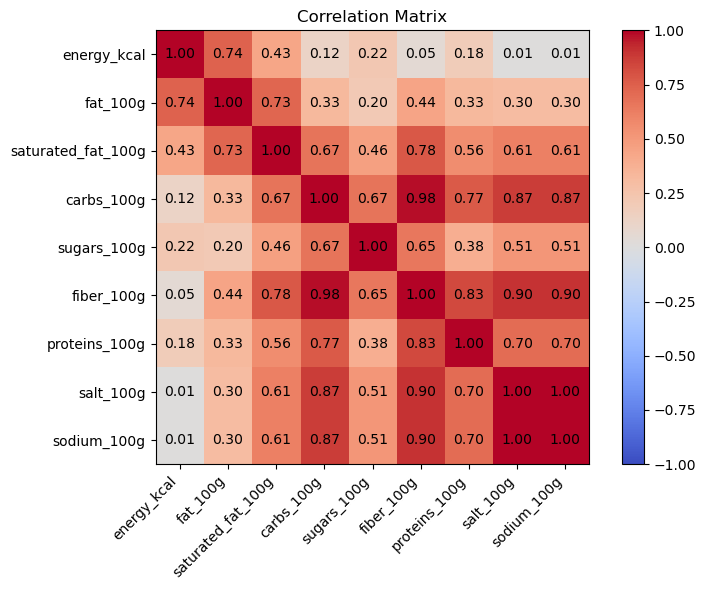

In [8]:
# Here we look at correlations among the continuous columns

# list of continuous columns
cols_cont = ['energy_kcal','fat_100g','saturated_fat_100g','carbs_100g',
        'sugars_100g','fiber_100g','proteins_100g','salt_100g','sodium_100g']

# find correlations
corr = df[cols_cont].corr()

# plot the correlations
fig, ax = plt.subplots(figsize=(8, 6))

cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# ticks + labels
ax.set_xticks(np.arange(len(cols_cont)))
ax.set_yticks(np.arange(len(cols_cont)))
ax.set_xticklabels(cols_cont, rotation=45, ha='right')
ax.set_yticklabels(cols_cont)

# add values inside cells
for i in range(len(cols_cont)):
    for j in range(len(cols_cont)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

# colorbar
fig.colorbar(cax)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Here we can see that salt and sodium are perfectly correlated columns. There are other high correlations such as with fiber and salt

# Pie Charts

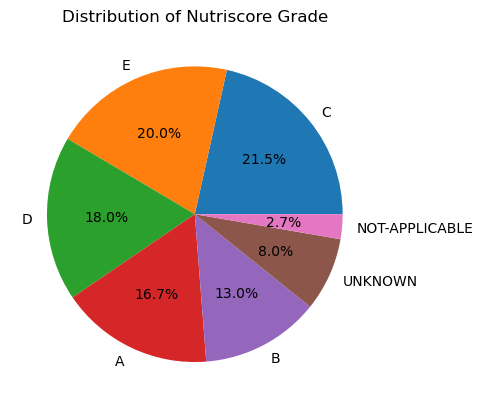

In [9]:
# Here we make a pie chart for the distribution of nutriscore grades
counts = df['nutriscore_grade'].value_counts()

# plot
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of Nutriscore Grade")

plt.show()

### Here one can see that the categories are mostly balanced except for not applicable and unknown, which have lower frequencies. 

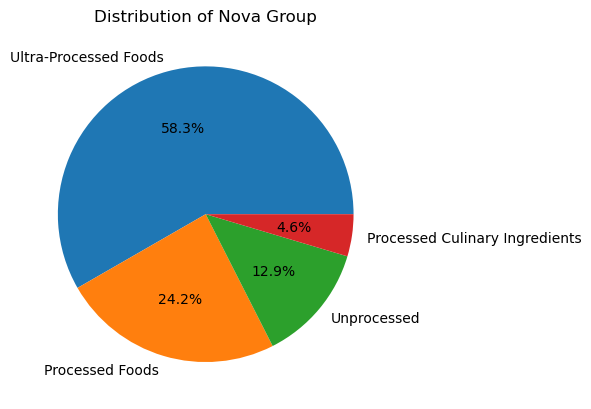

In [10]:
# Here we make a pie chart for the nova group
nova_map = {
    1: "Unprocessed",
    2: "Processed Culinary Ingredients",
    3: "Processed Foods",
    4: "Ultra-Processed Foods"
}

df['nova_group_label'] = df['nova_group'].map(nova_map)

counts = df['nova_group_label'].value_counts()

# plot
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of Nova Group")

plt.show()

### Here you can see that the majority of the feature is group 4, followed by 3, then 1, then 2. The score is in descending order from least to most processed. This shows that most of the food was ultra processed.

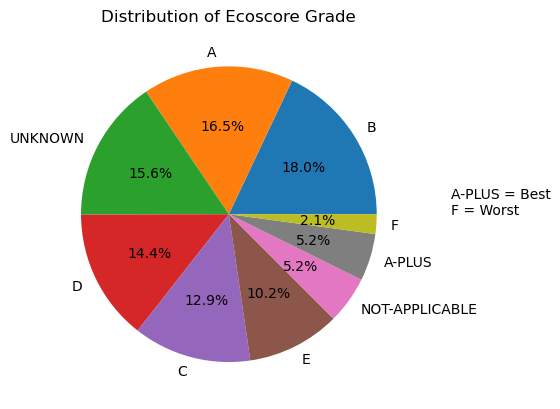

In [11]:
# Here is a pie chart for the ecoscore grade distribution
counts = df['ecoscore_grade'].value_counts()

# plot
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Distribution of Ecoscore Grade")
plt.text(
    1.5, 0,                
    "A-PLUS = Best\nF = Worst",
    fontsize=10
)

plt.show()

### Here you can see that the grades are mostly balanced except for F, A-Plus, and not applicable, which have smaller frequencies.

In [12]:
# make a list of boolean columns
bool_cols = [
    'contains_gluten',
    'contains_dairy',
    'contains_nuts',
    'contains_soy',
    'contains_eggs',
    'contains_fish'
]

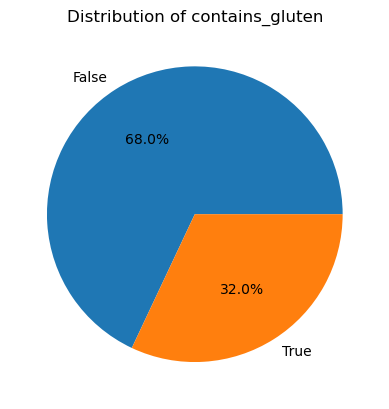

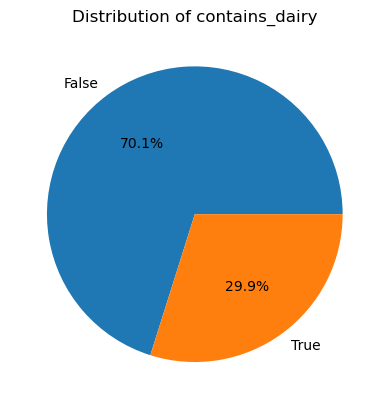

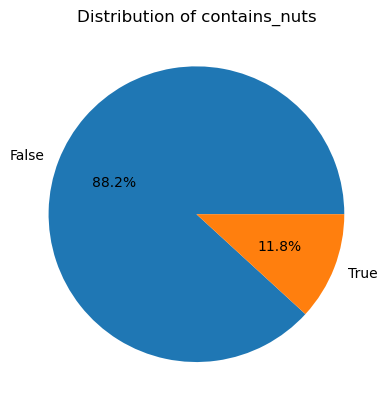

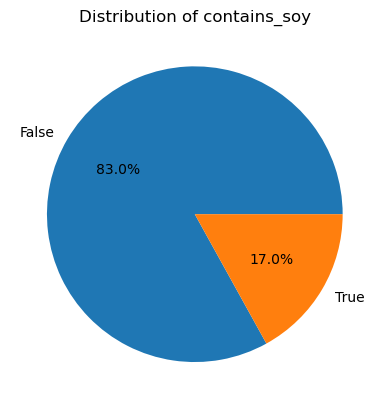

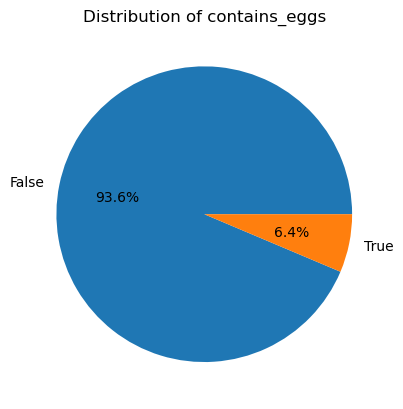

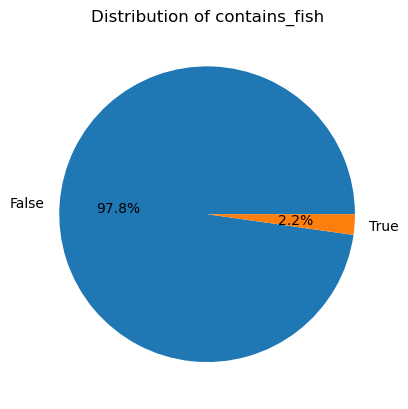

In [13]:
# Loop that creates pie charts for all the boolean columns
for col in bool_cols:

    counts = df[col].value_counts()
    # plot
    plt.figure()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"Distribution of {col}")

    plt.show()

### Here one can see that 32% contain gluten, 29.9% contain dairy, 11.8% contain nuts, 17% contain soy, 6.4% contain eggs, and 2.2% contain fish.

# Histograms

### One can see that the distribution is quite right-skewed with a peak on the far left

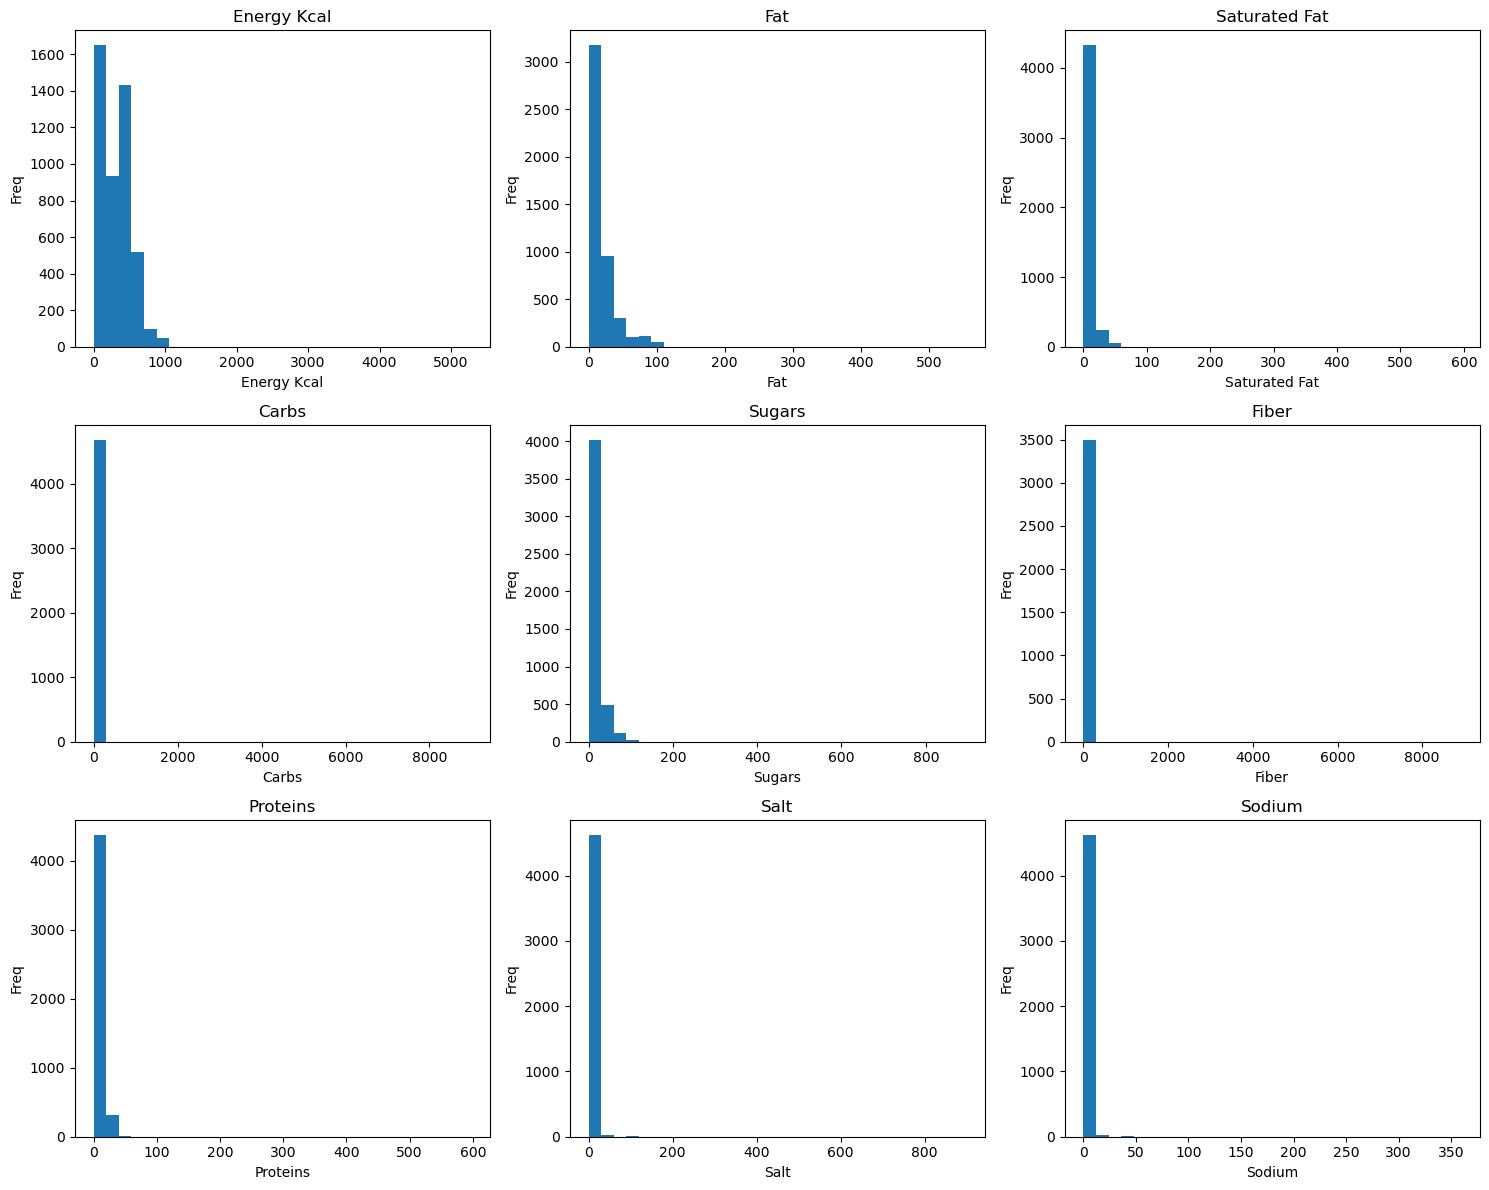

In [14]:
nutrition_cols = ['energy_kcal', 'fat_100g', 'saturated_fat_100g', 'carbs_100g', 'sugars_100g',
                  'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']

# create 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(nutrition_cols):
    label = col.replace('_100g', '').replace('_', ' ')
    
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(f"{label.title()}")
    axes[i].set_xlabel(label.title())
    axes[i].set_ylabel("Freq")

# adjust spacing
plt.tight_layout()

plt.show()

### Here we can see that all of the distributions are highly right-skewed and that all of the peaks are on the far left.

In [15]:
skew_vals = df[cols_cont].skew()

print(skew_vals)

energy_kcal            2.758257
fat_100g               4.709470
saturated_fat_100g    24.231458
carbs_100g            64.027420
sugars_100g           15.053562
fiber_100g            58.730856
proteins_100g         32.252818
salt_100g             49.537405
sodium_100g           49.537541
dtype: float64


# Conclusion

### We started by loading in the data and dropping columns that were either ids or had too many categories. We then checked the five number summaries for the continuous columns and looked at their correlations. We also checked the number of missing values per feature. After that, we made pie charts for the categorical features and histograms for the continuous features. We noticed that the continuous features were all highly right-skewed. We confirmed this by calcuating the skewness metrics for those columns were above 1, showing high right-skewness.